# SVM Classification Model  (Linear SVM)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
DATA_DIR = Path("data")

X_train = pd.read_csv(
    DATA_DIR / "(experiment) X_train.csv",
    index_col=0,
    parse_dates=True
)

y_train = pd.read_csv(
    DATA_DIR / "(experiment) y_train.csv",
    index_col=0,
    parse_dates=True
)

X_test = pd.read_csv(
    DATA_DIR / "(experiment) X_test.csv",
    index_col=0,
    parse_dates=True
)

y_test = pd.read_csv(
    DATA_DIR / "(experiment) y_test.csv",
    index_col=0,
    parse_dates=True
)

In [3]:
print("=" * 50)
print("TRAIN / TEST SPLIT")
print("=" * 50)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining period:")
print(X_train.index.min(), "to", X_train.index.max())

print("\nTesting period:")
print(X_test.index.min(), "to", X_test.index.max())

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

TRAIN / TEST SPLIT
Training observations: 59
Testing observations: 18

Training period:
2007-06-30 00:00:00 to 2021-12-31 00:00:00

Testing period:
2022-03-31 00:00:00 to 2026-06-30 00:00:00

Training class distribution:
PCE_Regime
0             29
1             30
Name: count, dtype: int64

Testing class distribution:
PCE_Regime
0              8
1             10
Name: count, dtype: int64


# 1. Import SVM

In [4]:
# ============================================================
# SVM CLASSIFICATION MODEL
# PCE Growth Regime Classification
# ============================================================

from sklearn.svm import SVC

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# 2. Build the SVM pipeline

In [5]:
# ============================================================
# BUILD LINEAR SVM PIPELINE
# ============================================================

svm_pipeline = Pipeline([
    
    # Handle missing values using training medians
    ("imputer", SimpleImputer(strategy="median")),
    
    # Standardize economic predictors
    ("scaler", StandardScaler()),
    
    # Linear Support Vector Machine
    ("svm", SVC(
        kernel="linear",     # "linear" -- testing a linear decision boundary
        C=1.0,
        probability=True,
        random_state=42
    ))
    
])

print(svm_pipeline)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('svm',
                 SVC(kernel='linear', probability=True, random_state=42))])


# 3. Train SVM

In [6]:
svm_pipeline.fit(X_train,y_train)

/usr/local/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

# 4. Generate predictions

In [8]:
# ============================================================
# SVM TEST PREDICTIONS
# ============================================================

svm_pred = svm_pipeline.predict(X_test)

svm_prob = svm_pipeline.predict_proba(X_test)[:, 1]


svm_predictions = pd.DataFrame({
    "Actual": y_test.squeeze(),
    "Predicted": svm_pred,
    "Probability_Strong": svm_prob
})

display(svm_predictions)

,Actual,Predicted,Probability_Strong
Quarter,,,
2022-03-31,0,1,0.556435
2022-06-30,1,0,0.511554
2022-09-30,0,0,0.479108
2022-12-31,0,0,0.508309
2023-03-31,1,0,0.512624
2023-06-30,0,1,0.550201
2023-09-30,1,1,0.559376
2023-12-31,1,1,0.583663
2024-03-31,0,1,0.565737


# 5. Calculate SVM metrics

In [9]:
# ============================================================
# SVM PERFORMANCE METRICS
# ============================================================

svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

svm_balanced_accuracy = balanced_accuracy_score(
    y_test,
    svm_pred
)

svm_precision = precision_score(
    y_test,
    svm_pred,
    zero_division=0
)

svm_recall = recall_score(
    y_test,
    svm_pred,
    zero_division=0
)

svm_f1 = f1_score(
    y_test,
    svm_pred,
    zero_division=0
)

svm_roc_auc = roc_auc_score(
    y_test,
    svm_prob
)


print("=" * 55)
print("SVM MODEL PERFORMANCE")
print("=" * 55)

print(f"Accuracy:           {svm_accuracy:.4f}")
print(f"Balanced Accuracy:  {svm_balanced_accuracy:.4f}")
print(f"Precision:          {svm_precision:.4f}")
print(f"Recall:             {svm_recall:.4f}")
print(f"F1 Score:           {svm_f1:.4f}")
print(f"ROC-AUC:            {svm_roc_auc:.4f}")

SVM MODEL PERFORMANCE
Accuracy:           0.4444
Balanced Accuracy:  0.4250
Precision:          0.5000
Recall:             0.6000
F1 Score:           0.5455
ROC-AUC:            0.5750


# 6. Classification report

In [10]:
# ============================================================
# SVM CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        svm_pred,
        target_names=[
            "Weak Growth",
            "Strong Growth"
        ],
        zero_division=0
    )
)

               precision    recall  f1-score   support

  Weak Growth       0.33      0.25      0.29         8
Strong Growth       0.50      0.60      0.55        10

     accuracy                           0.44        18
    macro avg       0.42      0.42      0.42        18
 weighted avg       0.43      0.44      0.43        18



# 7. Confusion matrix

In [11]:
# ============================================================
# SVM CONFUSION MATRIX
# ============================================================

svm_cm = confusion_matrix(
    y_test,
    svm_pred
)

print("SVM Confusion Matrix:")
print(svm_cm)

SVM Confusion Matrix:
[[2 6]
 [4 6]]


$$
\begin{bmatrix}
TN=2 & FP=6 \\
FN=4 & TP=6
\end{bmatrix}
$$

TN = Weak Growth correctly predicted as Weak\
FP = Weak Growth incorrectly predicted as Strong

FN = Strong Growth incorrectly predicted as Weak\
TP = Strong Growth correctly predicted as Strong

- Of 8 actual Weak-Growth quarters, SVM correctly identified only 2.
- Of 10 actual Strong-Growth quarters, SVM correctly identified 6.
- It incorrectly classified 6 Weak quarters as Strong.
- It incorrectly classified 4 Strong quarters as Weak.

**The model is therefore still biased toward predicting Strong Growth, although it is not as extreme as KNN.**


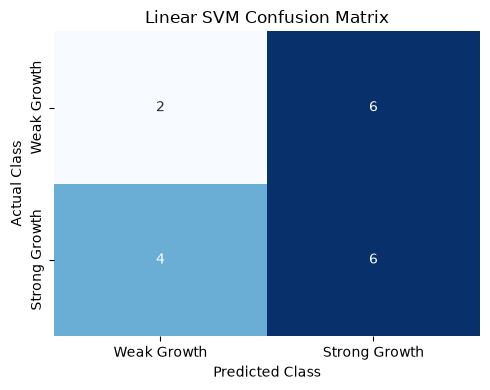

In [14]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "Weak Growth",
        "Strong Growth"
    ],
    yticklabels=[
        "Weak Growth",
        "Strong Growth"
    ]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "Linear SVM Confusion Matrix"
)

plt.tight_layout()
plt.show()

# 8. Save the SVM result

In [15]:
# ============================================================
# SVM RESULT TABLE
# ============================================================

svm_results = pd.DataFrame({
    "Model": ["SVM (Linear)"],
    "Accuracy": [svm_accuracy],
    "Balanced Accuracy": [svm_balanced_accuracy],
    "Precision": [svm_precision],
    "Recall": [svm_recall],
    "F1": [svm_f1],
    "ROC-AUC": [svm_roc_auc]
})

display(svm_results.round(4))

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
0,SVM (Linear),0.4444,0.425,0.5,0.6,0.5455,0.575


| Metric            | **Linear SVM** | Interpretation                                               |
| ----------------- | -------------: | ------------------------------------------------------------ |
| Accuracy          |     **0.4444** | 44.44% of test quarters were classified correctly            |
| Balanced Accuracy |     **0.4250** | Average performance across Weak and Strong classes was 42.5% |
| Precision         |     **0.5000** | When predicting Strong Growth, 50% were actually Strong      |
| Recall            |     **0.6000** | It identified 60% of the actual Strong-Growth quarters       |
| F1                |     **0.5455** | Moderate balance between precision and recall                |
| ROC-AUC           |     **0.5750** | Probability ranking was slightly better than random          |


### Interpretation: 

Linear SVM did not collapse completely to one class, but its balanced accuracy below 0.50 indicates weak overall class discrimination.

# 9. Optional but useful — inspect Linear SVM coefficients

In [16]:
# ============================================================
# LINEAR SVM COEFFICIENTS
# ============================================================

fitted_svm = svm_pipeline.named_steps["svm"]

svm_coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": fitted_svm.coef_[0]
})

In [17]:
# Positive coefficients
svm_positive_coef = (
    svm_coef_df[
        svm_coef_df["Coefficient"] > 0
    ]
    .sort_values(
        "Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)


# Negative coefficients
svm_negative_coef = (
    svm_coef_df[
        svm_coef_df["Coefficient"] < 0
    ]
    .sort_values(
        "Coefficient",
        ascending=True
    )
    .reset_index(drop=True)
)


print("TOP POSITIVE SVM COEFFICIENTS")
print("Direction toward Class 1 = Strong Growth")

display(
    svm_positive_coef.head(10)
)


print("\nTOP NEGATIVE SVM COEFFICIENTS")
print("Direction toward Class 0 = Weak Growth")

display(
    svm_negative_coef.head(10)
)

TOP POSITIVE SVM COEFFICIENTS
Direction toward Class 1 = Strong Growth


,Feature,Coefficient
0,Savings Rate,1.012368
1,Dividend Income,1.011847
2,Tax Refunds,0.884573
3,Personal Savings,0.692597
4,Delinquency Rate,0.544430
5,Quit Rate,0.509186
6,Treasury Yield,0.499586
7,Auto Loan Rate,0.473608
8,Prime Rate,0.331190
9,Financial Assets,0.324888



TOP NEGATIVE SVM COEFFICIENTS
Direction toward Class 0 = Weak Growth


,Feature,Coefficient
0,Economic Policy Uncertainty,-0.810234
1,Inflation Expectations,-0.808984
2,Average Weekly Hours,-0.772096
3,Transportation Inflation,-0.690254
4,Homeownership Rate,-0.685131
5,Weekly Earnings,-0.669615
6,Vehicle Sales,-0.653587
7,Job Openings (JOLTS),-0.617434
8,Corporate Bond Yield,-0.615239
9,Consumer Sentiment Index,-0.595168


**Interpretation**: 

In a linear SVM, these coefficients describe the orientation of the separating hyperplane, not probabilities or causal effects. 

A **positive coefficient** pushes the SVM decision function toward **Class 1**;\
a **negative coefficient** pushes it toward **Class 0**, holding the other standardized predictors fixed.

| Model               | Question                                                       |
| ------------------- | -------------------------------------------------------------- |
| Dummy               | What happens without useful feature-based learning?            |
| Logistic Regression | Is there useful **linear probabilistic** signal?               |
| KNN                 | Do **similar economic quarters** belong to similar regimes?    |
| **Linear SVM**      | Can a **maximum-margin boundary** better separate the regimes? |
| Decision Tree       | Are **nonlinear threshold rules** useful?                      |
| Random Forest       | Do **multiple nonlinear interactions** improve prediction?     |
| XGBoost             | Can **sequential boosting** extract stronger structure?        |
